# DARTS model for the hydrogen reservoir in Bourakébougou

The tank model gives the pressure of the reservoir as one value. Here I divide the reservoir into a three-dimensional grid and calculate how hydrogen and water move between the cells. This is the second DARTS model and the third model in this research.

The starting point is the shallow hydrogen accumulation described by Maiga et al. (2023). The gas is approximately 98% hydrogen, 1% nitrogen and 1% methane on a dry basis. Hydrogen can dissolve into the water and come out of solution when the conditions change. I kept temperature constant for this model.

The dimensions, permeability, porosity, temperature and well settings below are assumptions. The calculation is a research example for Bourakébougou, not a history match or an estimate of the field reserves.

## Importing the packages

I use the existing DARTS environment. The `.py` files contain the fluid properties, reservoir grid and calculation, so I can change the input values here without copying the solver into every cell.

In [1]:
from pathlib import Path
import sys
import json
import contextlib
import io
import numpy as np
from IPython.display import display, Image

expected_python = Path('/Users/sanderbertdacosta/.local/share/python-envs/darts-py311/bin/python').resolve()
assert Path(sys.executable).resolve() == expected_python, 'Select the darts-local kernel.'
project = next((p for p in [Path.cwd(), *Path.cwd().parents]
                if (p / 'white_hydrogen' / 'bourakebougou' / 'model.py').exists()), None)
assert project is not None, 'Open this notebook inside the reservoir simulation project.'
if str(project) not in sys.path:
    sys.path.insert(0, str(project))
from white_hydrogen.bourakebougou.properties import load_config
from white_hydrogen.bourakebougou.run import run_case, run_suite
folder = project / 'white_hydrogen' / 'bourakebougou'
print('Python:', sys.executable)

Python: /Users/sanderbertdacosta/.local/share/python-envs/darts-py311/bin/python


## Reservoir properties

The initial pressure is specified at a depth in the gas cap. The water pressure increases more strongly with depth because water is much denser than hydrogen. Capillary pressure determines how much water remains above the assumed gas–water contact. The gas contains water vapour, while the aqueous phase contains dissolved gases.

All pressures are absolute bar. DARTS uses metres, days, mD, cP and kmol internally. `hydrogen_recharge_kg_day` and `water_influx_kg_day` describe separate external inputs. They are zero in the closed case.

In [2]:
parameters = {}  # For example: {'permeability_md': 5.0, 'runtime_days': 730.0}
config = load_config(parameters)
for key in ['nx', 'ny', 'nz', 'length_x_m', 'length_y_m', 'thickness_m',
            'top_depth_m', 'gas_water_contact_depth_m', 'datum_depth_m',
            'datum_pressure_bar', 'temperature_k', 'porosity', 'permeability_md',
            'producer_bhp_bar', 'runtime_days']:
    print(f'{key}: {config[key]}')

nx: 9
ny: 9
nz: 9
length_x_m: 1000.0
length_y_m: 1000.0
thickness_m: 45.0
top_depth_m: 100.0
gas_water_contact_depth_m: 125.0
datum_depth_m: 110.0
datum_pressure_bar: 6.0
temperature_k: 303.15
porosity: 0.1
permeability_md: 10.0
producer_bhp_bar: 3.0
runtime_days: 365.0


## Calculating the component balance

For each component, the mass remaining in the reservoir is

$$M_i(t)=M_i(0)+M_{i,\mathrm{in}}(t)-M_{i,\mathrm{produced}}(t).$$

The index $i$ denotes hydrogen, nitrogen, methane or water. Moving hydrogen between the gas and water phases does not change its total mass. I calculate production from the native well connection and integrate the rates at each accepted timestep. This gives an independent check against the change in stored mass.

The gas density comes from a mixture equation of state. The aqueous phase uses a gas-solubility calculation with IAPWS water properties. Independent Henry-law and NIST comparisons are included in the tests.

In [3]:
# False reads the completed calculation supplied with this notebook.
# Set True after changing parameters to calculate the case again.
rerun = False
output = folder / 'output' / 'closed'
if rerun:
    with contextlib.redirect_stdout(io.StringIO()):
        summary, history, snapshots = run_case(parameters, output)
else:
    status = json.loads((output / 'status.json').read_text())
    assert status['status'] == 'complete', 'Run the simulation before reading its results.'
    summary = json.loads((output / 'summary.json').read_text())
    assert summary['parameters'] == config, 'Inputs changed: set rerun = True.'
    print('Reading the completed native DARTS calculation.')
print(f"Hydrogen produced: {summary['produced_component_kg']['H2']:,.1f} kg")
print(f"Final mean reservoir pressure: {summary['final_pressure_mean_bar']:.4f} bar")
print(f"Hydrogen remaining in water: {summary['remaining_dissolved_H2_kg']:,.1f} kg")
print('Largest relative component balance residual:',
      max(summary['max_relative_component_balance_error'].values()))

Reading the completed native DARTS calculation.
Hydrogen produced: 21,915.5 kg
Final mean reservoir pressure: 6.2624 bar
Hydrogen remaining in water: 25,084.5 kg
Largest relative component balance residual: 5.395332184233708e-11


## Pressure and production over time

The plots show pressure, cumulative production, hydrogen in each phase and produced gas composition. The component-balance residual shows the numerical error in the calculation. It does not measure how closely the model represents the field.

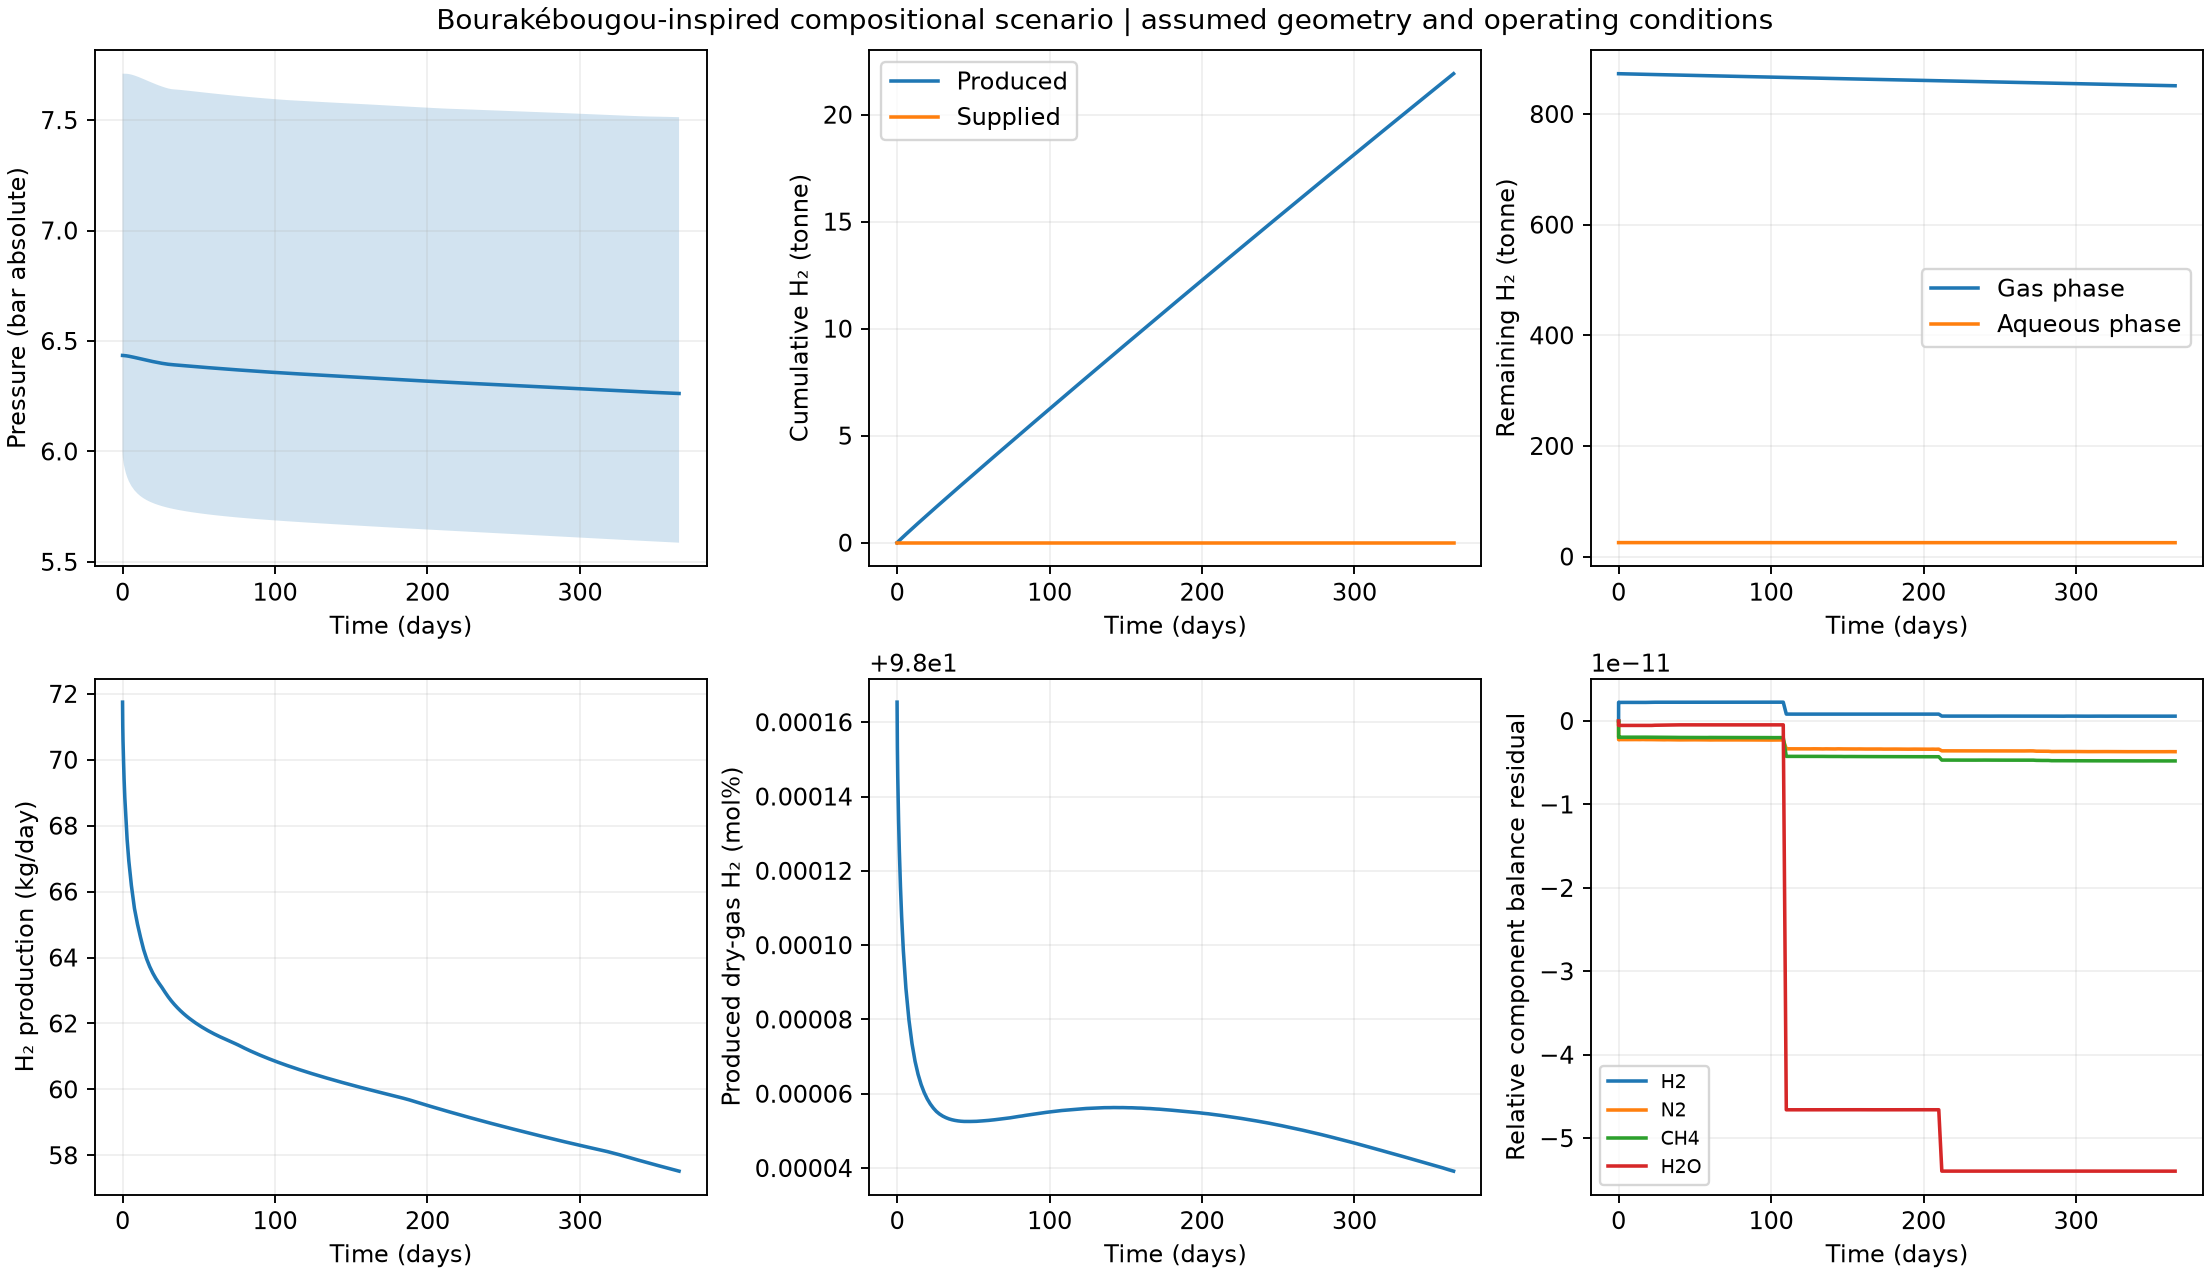

In [4]:
display(Image(filename=str(output / 'production.png')))

## The reservoir in three dimensions

These figures show calculated cell values, with the vertical scale expanded so that the layers are visible. The red well symbol marks the production completion. The vertical section helps us see the gas cap and the water below it. The initial and final fields are also saved as VTK files for viewing in a 3D scientific viewer.

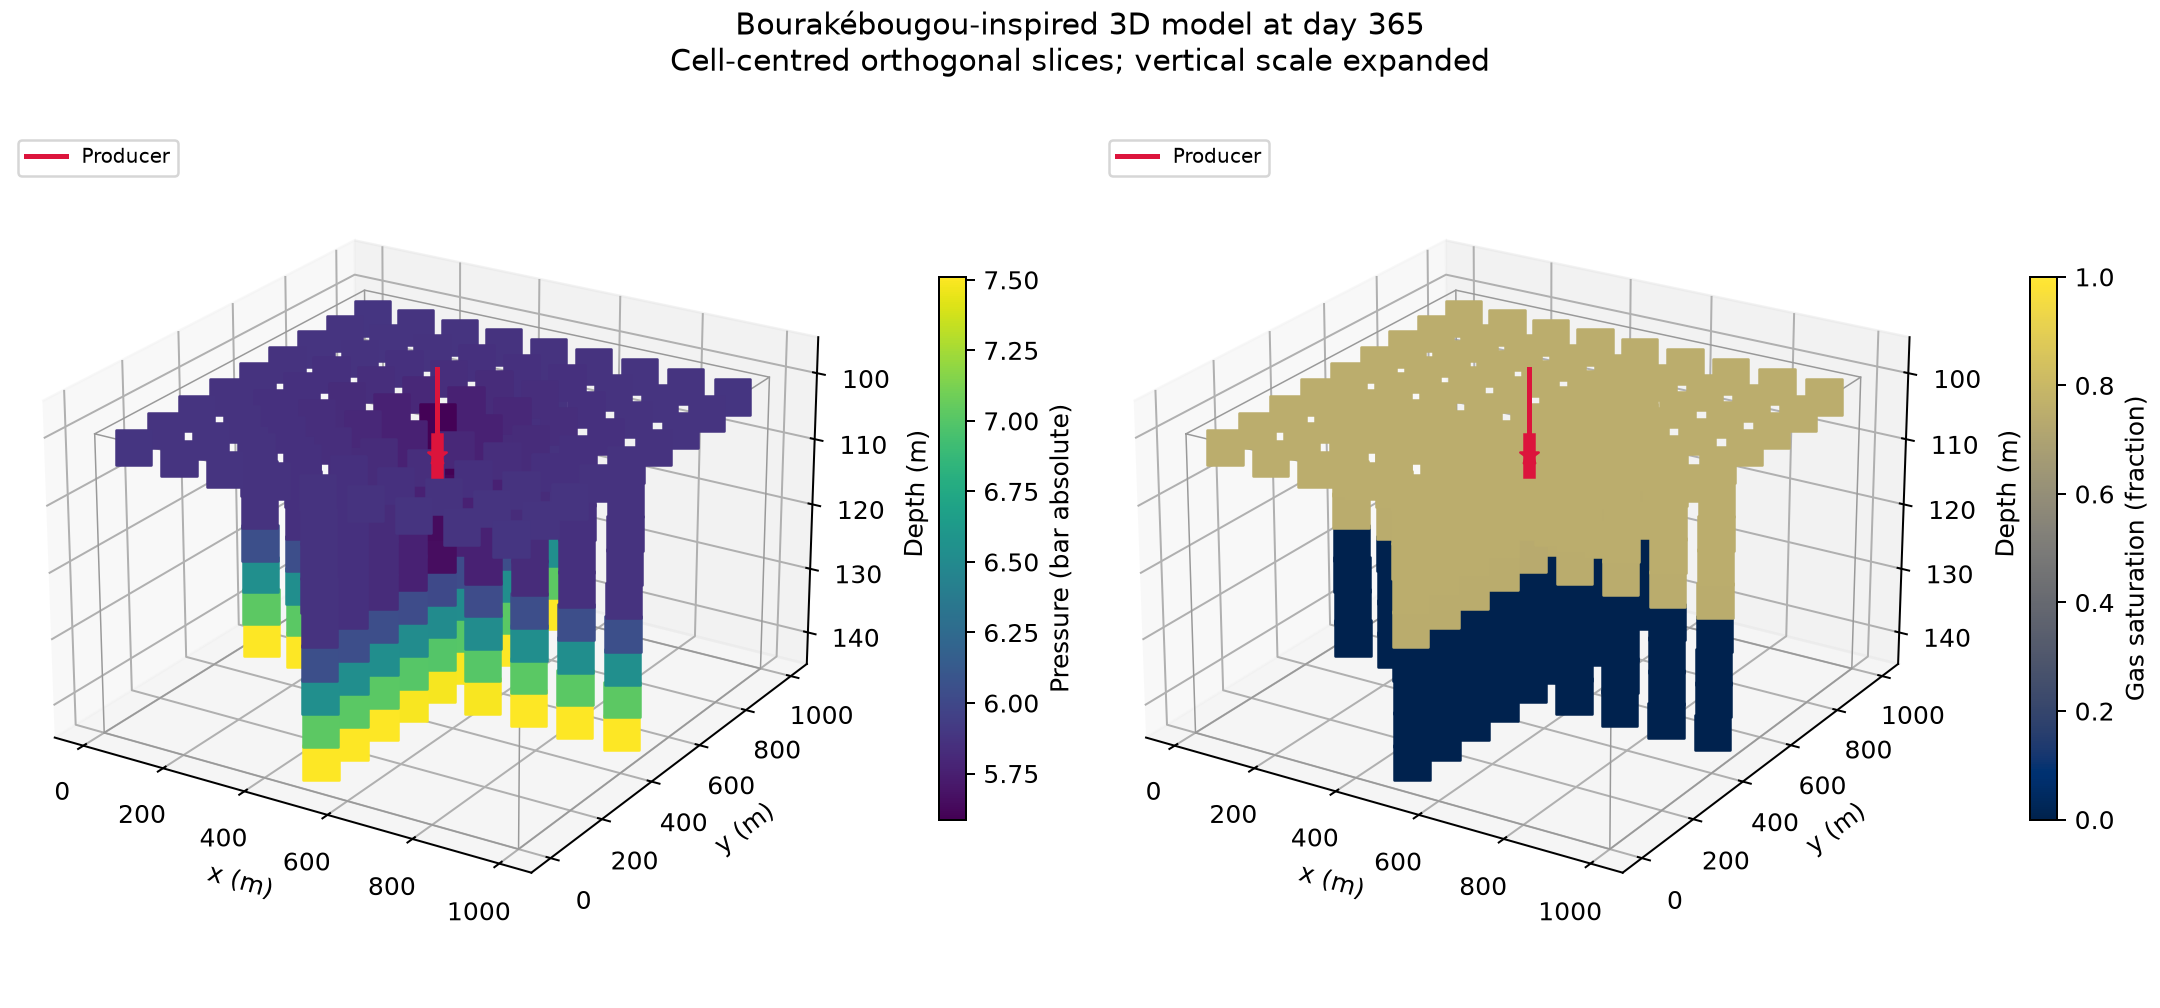

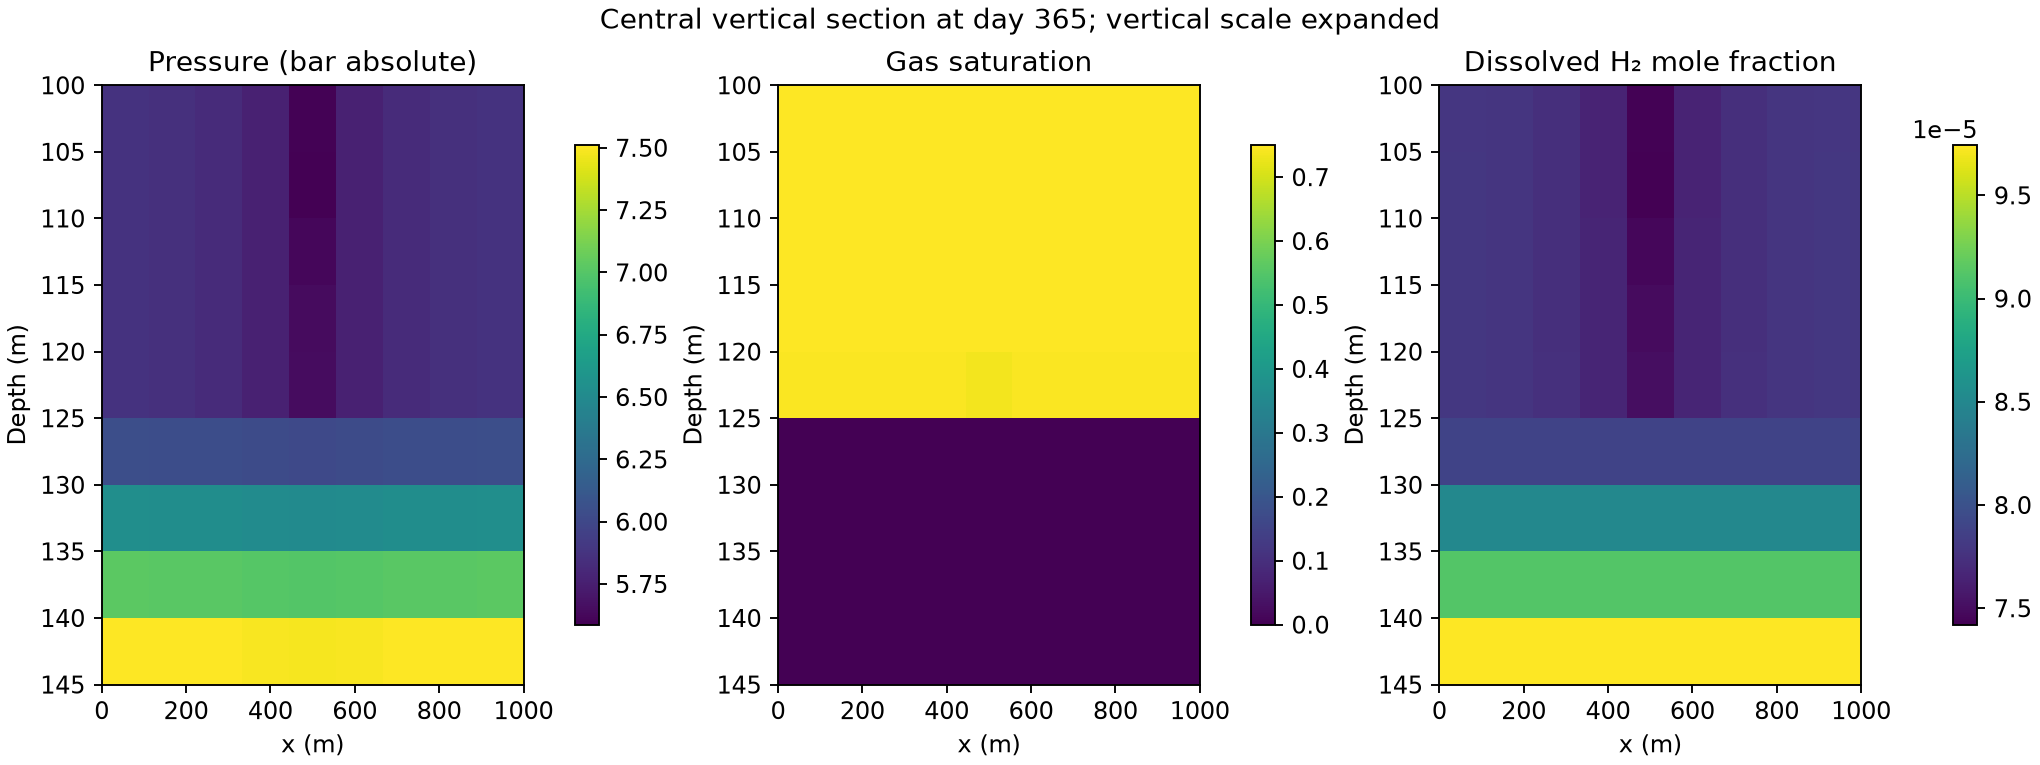

In [5]:
display(Image(filename=str(output / 'reservoir_3d.png')))
display(Image(filename=str(output / 'vertical_sections.png')))

## Comparing water influx and hydrogen supply

Pressure support can have different causes. We compare the closed case with a prescribed water influx, a prescribed hydrogen supply and a reduced gas-mobility case. These are independent sensitivities with stated inputs. They are not measured regeneration rates.

The lower gas-mobility endpoint is motivated by published carbonate experiments. The complete laboratory curve is retained for comparison, but its high-pressure, warm-brine conditions are different from the assumed shallow reservoir. I did not treat it as a measured Bourakébougou curve.

closed                    21.915 tonne H2    6.262 bar
water_influx              22.509 tonne H2    6.526 bar
hydrogen_supply           22.837 tonne H2    6.625 bar
lower_gas_mobility         5.050 tonne H2    6.355 bar


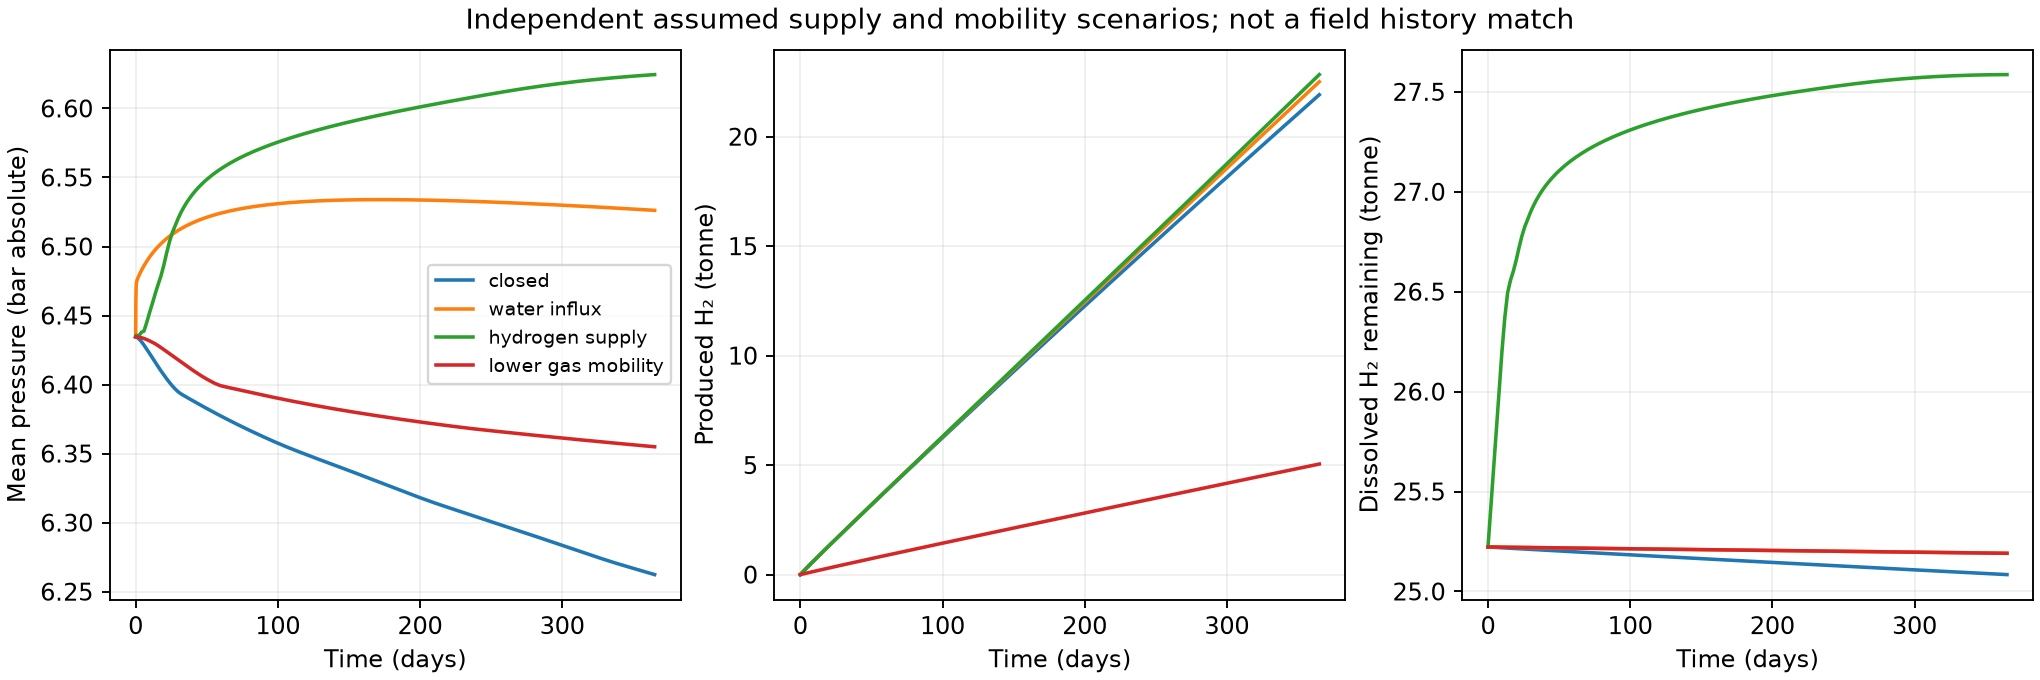

In [6]:
# Reproduce all supplied scenarios from a terminal with:
# ./run_darts.sh white_hydrogen/bourakebougou/run.py --suite
suite = json.loads((folder / 'output' / 'scenario_summary.json').read_text())
for name, result in suite.items():
    print(f"{name:22s} {result['produced_component_kg']['H2']/1000:9.3f} tonne H2"
          f"  {result['final_pressure_mean_bar']:7.3f} bar")
display(Image(filename=str(folder / 'output' / 'scenario_comparison.png')))

## Checking the results

The checks include phase appearance, conservation of every component, closed-reservoir relaxation, known external inputs, and smaller timesteps and grid cells. The property-interpolation spacing is also refined. Read `validation.json` for the settings and numerical differences.

A good mass balance is necessary, but field accuracy also needs measured pressure with a known datum, production history, pore volume, fluid chemistry, well tests and representative rock-flow properties.

In [7]:
verification = json.loads((folder / 'output' / 'validation.json').read_text())
assert verification['passed'], 'Inspect failed numerical checks before using the results.'
print(f"{sum(verification['checks'].values())} numerical checks passed.")
for key, value in verification['results']['refinement_metrics'].items():
    print(key, value)

19 numerical checks passed.
timestep_H2_production_relative_difference 9.830739910644111e-05
timestep_mean_pressure_difference_bar 1.3302617887234192e-05
interpolation_H2_production_relative_difference 0.000247109300201048
interpolation_mean_pressure_difference_bar 0.013846273301896694
horizontal_grid_H2_production_relative_difference 0.04082351799340584
horizontal_grid_mean_pressure_difference_bar 0.0039992523234886335
further_horizontal_grid_H2_production_relative_difference 0.010973115597776627
further_horizontal_grid_mean_pressure_difference_bar 0.0009033688530335482
vertical_grid_H2_production_relative_difference 0.0029718697660605243
vertical_grid_mean_pressure_difference_bar 0.001777596245984725


## Sources and further explanation

- Maiga et al. (2023), [Bourakébougou reservoir characterization](https://doi.org/10.1038/s41598-023-38977-y).
- [IAPWS Henry guideline](https://iapws.org/technical-guidance/release/HenGuide) and [NIST hydrogen density](https://tsapps.nist.gov/publication/get_pdf.cfm?pub_id=832233) for independent property checks.
- Rezaei et al. (2022), [hydrogen–brine relative permeability in carbonate and sandstone](https://doi.org/10.1029/2022GL099433).

`SCIENCE.md` explains the fluid models, field evidence and limits. `README.md` explains the input files, runs and retained results. The minor paper discusses this model alongside the corrected tank and the intermediate DARTS model.